In [2]:
import os
from scipy.signal import savgol_filter
import re
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams, cycler
from matplotlib.cm import ScalarMappable
import sys
sys.path.append(os.path.join('c:\\', *os.getcwd().split('\\')[1:-1]))
from sgcc11 import *

In [3]:
fp = r'D:\DebianShared\JC_Lab\Data_exploration\organized_analysis\other_analysis_notebooks'
ringach_file = os.path.join(fp, 'dataset_2-27-2023.pkl')
natim_file = os.path.join(fp, 'natural_image_data_5-15-2023.pkl')

In [4]:
rdf = pd.read_pickle(ringach_file)
ndf = pd.read_pickle(natim_file)

In [5]:
r = r'Block_\d_'
runits = list(rdf['pop_by_unit'].columns[4:])
runits = [
    x.replace(re.findall(r, x)[0], '')
    for x in runits
]

In [6]:
r = r'_BLK\d'
nunits = []
for col in list(ndf.columns):
    units = ndf[col].single_units
    for unit in units:
        nunits.append(
            f"{col.replace(re.findall(r, col)[0], '')[3:]}_Unit_{unit}"
        )

In [7]:
shared_units = [x for x in nunits if x in runits]

In [8]:
newcolr = list(rdf['pop_by_unit'].columns[:4]) + runits
rdf['pop_by_unit'].columns = newcolr

In [9]:
gr = rdf['pop_by_unit'].groupby(['Orientation', 'Spatial Freq', 'Phase'])
dr = np.array([np.array([np.array(z) for z in x]) for x in gr.agg(list)[shared_units].values])
dr = savgol_filter(dr, 150, 8, mode = 'wrap', axis = 2) # apply smoothing
dr = dr.reshape(6,17,4,64,500)
ringach_resp = dr - dr[:,0,:,:,:].mean((0,1))[None,None,None,:,:] # baseline subtraction
ringach_resp = ringach_resp[:,1:] # drop baseline
ringach_resp = ringach_resp/ringach_resp.max((0,1,2,4))[None,None,None,:,None] # max norm

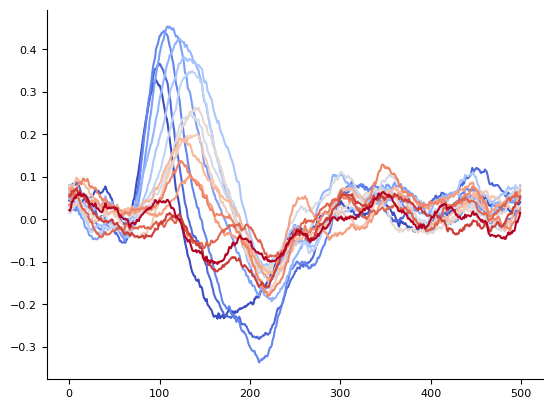

In [10]:
cmap = plt.get_cmap('coolwarm') 
rcParams['axes.prop_cycle'] = cycler(color=cmap(np.linspace(0, 1, 16)))
fig, ax = plt.subplots()

ax.plot(ringach_resp.mean((0,2))[:,0].T)
ax.tick_params(labelsize = 8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

In [11]:
r = r'_BLK\d'
ndf.columns = [x.replace(re.findall(r, x)[0], '') for x in list(ndf.columns)]

In [12]:
ni_sections = []
for i, sec_name in enumerate(list(ndf.columns)):
    sec = ndf[sec_name].population_by_cluster
    cond_col = list(sec.columns)[:4]
    unit_col = list(sec.columns)[4:]
    new_unit_col = [f"{sec_name[3:]}_Unit_{u}" for u in unit_col]
    newcol = cond_col + new_unit_col
    sec.columns = newcol
    if i == 0:
        ni_sections.append(sec)
    else:
        ni_sections.append(sec[new_unit_col])
ndf = ni_sections[0].join(ni_sections[1:])
ndf = ndf.loc[ndf['size'] == 60]
ndf = ndf.drop(['size', 'file'], axis = 1)

In [15]:
list(ndf.columns)

['stimulus_condition',
 'filter',
 'M013_Section_1_Unit_2',
 'M013_Section_1_Unit_8',
 'M013_Section_1_Unit_66',
 'M013_Section_1_Unit_67',
 'M013_Section_1_Unit_69',
 'M013_Section_1_Unit_70',
 'M013_Section_1_Unit_72',
 'M016_Section_1_Unit_3',
 'M016_Section_1_Unit_6',
 'M016_Section_1_Unit_8',
 'M016_Section_1_Unit_10',
 'M016_Section_1_Unit_14',
 'M016_Section_1_Unit_39',
 'M016_Section_1_Unit_40',
 'M016_Section_1_Unit_44',
 'M016_Section_1_Unit_66',
 'M016_Section_1_Unit_69',
 'M016_Section_1_Unit_70',
 'M016_Section_1_Unit_71',
 'M016_Section_1_Unit_73',
 'M016_Section_1_Unit_75',
 'M016_Section_1_Unit_76',
 'M017_Section_1_Unit_3',
 'M017_Section_1_Unit_8',
 'M017_Section_1_Unit_9',
 'M017_Section_1_Unit_10',
 'M017_Section_1_Unit_11',
 'M017_Section_1_Unit_13',
 'M017_Section_1_Unit_38',
 'M017_Section_1_Unit_63',
 'M017_Section_1_Unit_68',
 'M019_Section_2_Unit_6',
 'M019_Section_2_Unit_7',
 'M019_Section_2_Unit_8',
 'M019_Section_2_Unit_12',
 'M020_Section_1_Unit_2',
 'M020

In [12]:
gn = ndf.groupby(['filter', 'stimulus_condition']).agg(list)
dn = np.array([np.array([np.array(z) for z in x]) for x in gn[shared_units].values])
dn = savgol_filter(dn, 150, 8, mode = 'wrap', axis = 2) # apply smoothing
ni_responses = dn.reshape(3,60,64,500)
ni_responses = ni_responses/ni_responses.max((0,1,3))[None,None,:,None] # max norm

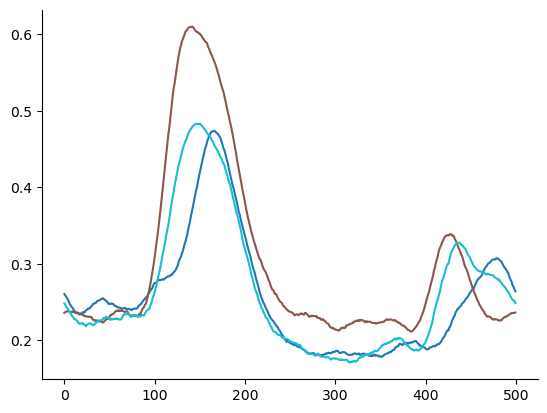

In [13]:
cmap = plt.get_cmap('tab10') 
rcParams['axes.prop_cycle'] = cycler(color=cmap(np.linspace(0, 1, 3)))
fig, ax = plt.subplots()

ax.plot(ni_responses.mean(1)[:,0].T)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

In [14]:
# shape = (ori, sf, phi, unit, t)
ringach_resp.shape

(6, 16, 4, 64, 500)

In [15]:
# shape = (filt_cond ['NI', 'LPF', 'HPF'], img_cond, unit, t)
ni_responses.shape

(3, 60, 64, 500)

In [16]:
# r_savepath = os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'project_datafiles', 'ringach_resp.pkl')
# with open(r_savepath, 'wb') as f:
#     pickle.dump(ringach_resp, f)

In [17]:
# n_savepath = os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'project_datafiles', 'ni_resp.pkl')
# with open(n_savepath, 'wb') as f:
#     pickle.dump(ni_responses, f)